# Задача 2. Реализация подсчёта треугольников

Реализация алгоритмов подсчёта треугольников в неориентированных графах с использованием `python-graphblas`.

In [1]:
import graphblas as gb

gb.init("suitesparse", blocking=False)

from graphblas import Matrix, Vector, dtypes, binary, monoid, semiring
from graphblas.io import mmread
import numpy as np

## Утилиты: загрузка, проверка и конвертация графов

In [2]:
def load_graph(path: str) -> Matrix:
    """Загрузка графа из файла Matrix Market (.mtx)."""
    return mmread(path)


def is_undirected(A: Matrix) -> bool:
    """Проверка неориентированности графа (симметричность матрицы смежности)."""
    if A.nrows != A.ncols:
        return False
    diff = A.ewise_add(A.T, op=binary.minus).new()
    diff = diff.apply(gb.unary.abs).new()
    total = diff.reduce_scalar(monoid.plus).new()
    return (total.value or 0) == 0


def to_undirected_bool(A: Matrix) -> Matrix:
    """Конвертация матрицы в симметричную булеву (неориентированный граф без весов).
    Удаляет петли (диагональные элементы).
    """
    sym = A.ewise_add(A.T, op=binary.pair).new(dtype=dtypes.INT64)
    sym << gb.select.offdiag(sym)
    return sym

## Алгоритмы подсчёта треугольников

### 1. Наивный алгоритм через $A^3$

$\text{triangles} = \frac{\text{trace}(A^3)}{6}$

Каждый треугольник учитывается 6 раз (3 стартовые вершины × 2 направления обхода).

In [3]:
def naive_a3(A: Matrix) -> int:
    """Наивный алгоритм: trace(A^3) / 6."""
    A3 = A.mxm(A.mxm(A).new()).new()
    trace = A3.diag().reduce(gb.agg.sum).new()
    return int(trace.value or 0) // 6

### 2. Наивный алгоритм с маской через $A^2$

$\text{triangles} = \frac{\sum(A^2 \circ A)}{6}$

Вместо вычисления полного $A^3$, вычисляем $A^2$ и маскируем результат матрицей $A$ (поэлементное произведение). Это эквивалентно подсчёту замыкающих рёбер.

In [4]:
def naive_mask_a2(A: Matrix) -> int:
    """Наивный алгоритм с маской: sum(A^2 ∘ A) / 6."""
    mask = A.dup(dtype=dtypes.BOOL)
    A2_masked = A.mxm(A).new(mask=mask)
    total = A2_masked.reduce_scalar(monoid.plus).new()
    return int(total.value or 0) // 6

### 3. Cohen's algorithm

$\text{triangles} = \frac{\sum(L \cdot U \circ A)}{2}$

Разделяем матрицу на нижнюю $L = \text{tril}(A)$ и верхнюю $U = \text{triu}(A)$ треугольные части.
Произведение $L \cdot U$ с маской $A$ даёт каждый треугольник ровно 2 раза.

In [5]:
def cohen(A: Matrix) -> int:
    """Cohen's algorithm: sum(tril(A) @ triu(A), mask=A) / 2."""
    L = gb.select.tril(A).new()
    U = gb.select.triu(A).new()
    mask = A.dup(dtype=dtypes.BOOL)
    C = L.mxm(U).new(mask=mask)
    total = C.reduce_scalar(monoid.plus).new()
    return int(total.value or 0) // 2

### 4. Sandia algorithm

$\text{triangles} = \sum(L \cdot L \circ L), \quad L = \text{tril}(A)$

Используем только нижнюю треугольную часть. Произведение $L \cdot L$ с маской $L$ считает каждый треугольник ровно один раз, так как для треугольника $(i, j, k)$ с $i > j > k$ путь $i \to k \to j$ замыкается ребром $(i, j) \in L$.

In [6]:
def sandia(A: Matrix) -> int:
    """Sandia algorithm: sum(L @ L, mask=L), L = tril(A)."""
    L = gb.select.tril(A).new()
    mask = L.dup(dtype=dtypes.BOOL)
    C = L.mxm(L).new(mask=mask)
    total = C.reduce_scalar(monoid.plus).new()
    return int(total.value or 0)

## Подсчёт треугольников по вершинам

Для каждой вершины $i$: количество треугольников = $\frac{1}{2}\sum_j (A^2 \circ A)_{i,j}$.

Элемент $(A^2 \circ A)_{i,j}$ равен числу общих соседей вершин $i$ и $j$ при наличии ребра $(i,j)$. Каждый треугольник через вершину $i$ вносит вклад через два инцидентных ребра, поэтому делим на 2.

In [7]:
def triangles_per_vertex(A: Matrix) -> Vector:
    """Для каждой вершины возвращает количество треугольников, в которых она участвует."""
    mask = A.dup(dtype=dtypes.BOOL)
    B = A.mxm(A).new(mask=mask)
    row_sums = B.reduce_rowwise(monoid.plus).new()
    result = row_sums.apply(binary.cdiv, right=2).new()
    return result

## Тесты

In [8]:
algorithms = {
    "naive_a3": naive_a3,
    "naive_mask_a2": naive_mask_a2,
    "cohen": cohen,
    "sandia": sandia,
}


def build_complete_graph(n: int) -> Matrix:
    """Полный граф K_n."""
    rows, cols = [], []
    for i in range(n):
        for j in range(n):
            if i != j:
                rows.append(i)
                cols.append(j)
    return Matrix.from_coo(rows, cols, [1] * len(rows), nrows=n, ncols=n, dtype=dtypes.INT64)


def build_path_graph(n: int) -> Matrix:
    """Путь (дерево) из n вершин: 0-1-2-..-(n-1)."""
    rows = list(range(n - 1)) + list(range(1, n))
    cols = list(range(1, n)) + list(range(n - 1))
    return Matrix.from_coo(rows, cols, [1] * len(rows), nrows=n, ncols=n, dtype=dtypes.INT64)


def run_all(A: Matrix) -> dict:
    return {name: fn(A) for name, fn in algorithms.items()}

### Тест 1: треугольник K3 (1 треугольник)

In [9]:
K3 = build_complete_graph(3)
results_k3 = run_all(K3)
print(f"K3: {results_k3}")
assert all(v == 1 for v in results_k3.values()), f"K3 expected 1, got {results_k3}"

tpv_k3 = triangles_per_vertex(K3)
print(f"K3 per vertex: {tpv_k3.to_dense()}")
assert tpv_k3.reduce(monoid.plus).new().value == 3 * 1  # sum = 3 * total_triangles
print("K3: OK")

K3: {'naive_a3': 1, 'naive_mask_a2': 1, 'cohen': 1, 'sandia': 1}
K3 per vertex: [1 1 1]
K3: OK


### Тест 2: полный граф K4 (4 треугольника)

In [10]:
K4 = build_complete_graph(4)
results_k4 = run_all(K4)
print(f"K4: {results_k4}")
assert all(v == 4 for v in results_k4.values()), f"K4 expected 4, got {results_k4}"

tpv_k4 = triangles_per_vertex(K4)
print(f"K4 per vertex: {tpv_k4.to_dense()}")
assert all(int(x) == 3 for x in tpv_k4.to_dense()), "K4: each vertex in 3 triangles"
assert tpv_k4.reduce(monoid.plus).new().value == 3 * 4
print("K4: OK")

K4: {'naive_a3': 4, 'naive_mask_a2': 4, 'cohen': 4, 'sandia': 4}
K4 per vertex: [3 3 3 3]
K4: OK


### Тест 3: путь (дерево) из 5 вершин (0 треугольников)

In [11]:
P5 = build_path_graph(5)
results_p5 = run_all(P5)
print(f"Path(5): {results_p5}")
assert all(v == 0 for v in results_p5.values()), f"Path expected 0, got {results_p5}"
print("Path(5): OK")

Path(5): {'naive_a3': 0, 'naive_mask_a2': 0, 'cohen': 0, 'sandia': 0}
Path(5): OK


### Тест 4: полный граф K5 (10 треугольников)

In [12]:
K5 = build_complete_graph(5)
results_k5 = run_all(K5)
print(f"K5: {results_k5}")
assert all(v == 10 for v in results_k5.values()), f"K5 expected 10, got {results_k5}"

tpv_k5 = triangles_per_vertex(K5)
print(f"K5 per vertex: {tpv_k5.to_dense()}")
assert all(int(x) == 6 for x in tpv_k5.to_dense()), "K5: each vertex in 6 triangles"
assert tpv_k5.reduce(monoid.plus).new().value == 3 * 10
print("K5: OK")

K5: {'naive_a3': 10, 'naive_mask_a2': 10, 'cohen': 10, 'sandia': 10}
K5 per vertex: [6 6 6 6 6]
K5: OK


### Тест 5: граф Karate Club (45 треугольников)

In [13]:
karate_raw = load_graph("../data/karate/karate.mtx")
karate = to_undirected_bool(karate_raw)

print(f"Karate: {karate.nrows} vertices, {karate.nvals} edges (directed)")
assert is_undirected(karate), "Karate graph should be undirected"

results_karate = run_all(karate)
print(f"Karate: {results_karate}")
assert all(v == 45 for v in results_karate.values()), f"Karate expected 45, got {results_karate}"

tpv_karate = triangles_per_vertex(karate)
total_check = int(tpv_karate.reduce(monoid.plus).new().value or 0)
print(f"Karate per-vertex sum: {total_check}, expected {3 * 45}")
assert total_check == 3 * 45
print("Karate: OK")

Karate: 34 vertices, 156 edges (directed)
Karate: {'naive_a3': 45, 'naive_mask_a2': 45, 'cohen': 45, 'sandia': 45}
Karate per-vertex sum: 135, expected 135
Karate: OK


### Тест 6: согласованность всех алгоритмов на графе USpowerGrid

In [14]:
power_raw = load_graph("../data/USpowerGrid/USpowerGrid.mtx")
power = to_undirected_bool(power_raw)

print(f"USpowerGrid: {power.nrows} vertices, {power.nvals} directed edges")
assert is_undirected(power)

results_power = run_all(power)
print(f"USpowerGrid: {results_power}")
values = list(results_power.values())
assert all(v == values[0] for v in values), f"All algorithms must agree, got {results_power}"
print(f"USpowerGrid: OK (all algorithms agree on {values[0]} triangles)")

USpowerGrid: 4941 vertices, 13188 directed edges
USpowerGrid: {'naive_a3': 651, 'naive_mask_a2': 651, 'cohen': 651, 'sandia': 651}
USpowerGrid: OK (all algorithms agree on 651 triangles)


Бенчмарк на 10 графах из SuiteSparse Matrix Collection

Фильтры: `Rutherford-Boeing Type = Binary`, `Special Structure = Symmetric`, `Nonzeros.Min = 10000`.

In [15]:
import os
import time
import urllib.request
import tarfile
import pandas as pd
import matplotlib.pyplot as plt

SUITESPARSE_GRAPHS = [
    ("AG-Monien", "airfoil1"),
    ("AG-Monien", "whitaker3"),
    ("AG-Monien", "crack"),
    ("AG-Monien", "3elt"),
    ("AG-Monien", "4elt"),
    ("AG-Monien", "vibrobox"),
    ("AG-Monien", "cti"),
    ("AG-Monien", "t60k"),
    ("AG-Monien", "wing"),
    ("AG-Monien", "body"),
]

DOWNLOAD_DIR = "../data/suitesparse"
BASE_URL = "https://suitesparse-collection-website.herokuapp.com/MM"


def download_graph(group: str, name: str) -> str:
    """Скачивает граф из SuiteSparse и возвращает путь к .mtx файлу."""
    graph_dir = os.path.join(DOWNLOAD_DIR, name)
    mtx_path = os.path.join(graph_dir, f"{name}.mtx")
    if os.path.exists(mtx_path):
        return mtx_path

    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    url = f"{BASE_URL}/{group}/{name}.tar.gz"
    tar_path = os.path.join(DOWNLOAD_DIR, f"{name}.tar.gz")

    print(f"  Downloading {group}/{name} ...")
    urllib.request.urlretrieve(url, tar_path)

    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DOWNLOAD_DIR)
    os.remove(tar_path)

    if not os.path.exists(mtx_path):
        for root, dirs, files in os.walk(graph_dir):
            for f in files:
                if f.endswith(".mtx"):
                    return os.path.join(root, f)
    return mtx_path


def load_suitesparse_graph(group: str, name: str) -> Matrix:
    mtx_path = download_graph(group, name)
    raw = mmread(mtx_path)
    return to_undirected_bool(raw)

In [16]:
def benchmark_graph(A: Matrix, n_runs: int = 3) -> dict:
    """Замеряет среднее время работы каждого алгоритма."""
    times = {}
    for name, fn in algorithms.items():
        elapsed = []
        for _ in range(n_runs):
            start = time.perf_counter()
            result = fn(A)
            end = time.perf_counter()
            elapsed.append(end - start)
        times[name] = {
            "mean_s": np.mean(elapsed),
            "std_s": np.std(elapsed),
            "result": result,
        }
    return times

In [17]:
print("Загрузка и бенчмарк графов из SuiteSparse...")
print("=" * 80)

ss_results = []
for group, name in SUITESPARSE_GRAPHS:
    try:
        A = load_suitesparse_graph(group, name)
        print(f"\n{name}: {A.nrows} вершин, {A.nvals} рёбер (направленных)")
        times = benchmark_graph(A)

        tri_counts = [t["result"] for t in times.values()]
        assert all(c == tri_counts[0] for c in tri_counts), \
            f"Inconsistent triangle counts for {name}: {tri_counts}"

        row = {"graph": name, "vertices": A.nrows, "edges": A.nvals, "triangles": tri_counts[0]}
        for algo_name, t in times.items():
            row[f"{algo_name}_s"] = t["mean_s"]
            print(f"  {algo_name}: {t['mean_s']:.4f}s (±{t['std_s']:.4f}s), triangles={t['result']}")
        ss_results.append(row)
    except Exception as e:
        print(f"  ERROR: {e}")

ss_df = pd.DataFrame(ss_results)
ss_df

Загрузка и бенчмарк графов из SuiteSparse...

airfoil1: 4253 вершин, 24578 рёбер (направленных)
  naive_a3: 0.0029s (±0.0004s), triangles=8034
  naive_mask_a2: 0.0010s (±0.0002s), triangles=8034
  cohen: 0.0007s (±0.0000s), triangles=8034
  sandia: 0.0006s (±0.0001s), triangles=8034

whitaker3: 9800 вершин, 57978 рёбер (направленных)
  naive_a3: 0.0059s (±0.0018s), triangles=19190
  naive_mask_a2: 0.0015s (±0.0001s), triangles=19190
  cohen: 0.0015s (±0.0001s), triangles=19190
  sandia: 0.0013s (±0.0001s), triangles=19190

crack: 10240 вершин, 60760 рёбер (направленных)
  naive_a3: 0.0077s (±0.0008s), triangles=20141
  naive_mask_a2: 0.0019s (±0.0001s), triangles=20141
  cohen: 0.0023s (±0.0011s), triangles=20141
  sandia: 0.0011s (±0.0001s), triangles=20141

3elt: 4720 вершин, 27444 рёбер (направленных)
  naive_a3: 0.0026s (±0.0000s), triangles=9000
  naive_mask_a2: 0.0011s (±0.0001s), triangles=9000
  cohen: 0.0014s (±0.0001s), triangles=9000
  sandia: 0.0006s (±0.0000s), triangles=9

,graph,vertices,edges,triangles,naive_a3_s,naive_mask_a2_s,cohen_s,sandia_s
0,airfoil1,4253,24578,8034,0.002911,0.000954,0.000699,0.000588
1,whitaker3,9800,57978,19190,0.005892,0.001517,0.001542,0.001348
2,crack,10240,60760,20141,0.007686,0.001921,0.002252,0.001110
3,3elt,4720,27444,9000,0.002617,0.001102,0.001356,0.000584


### Визуализация результатов бенчмарка SuiteSparse

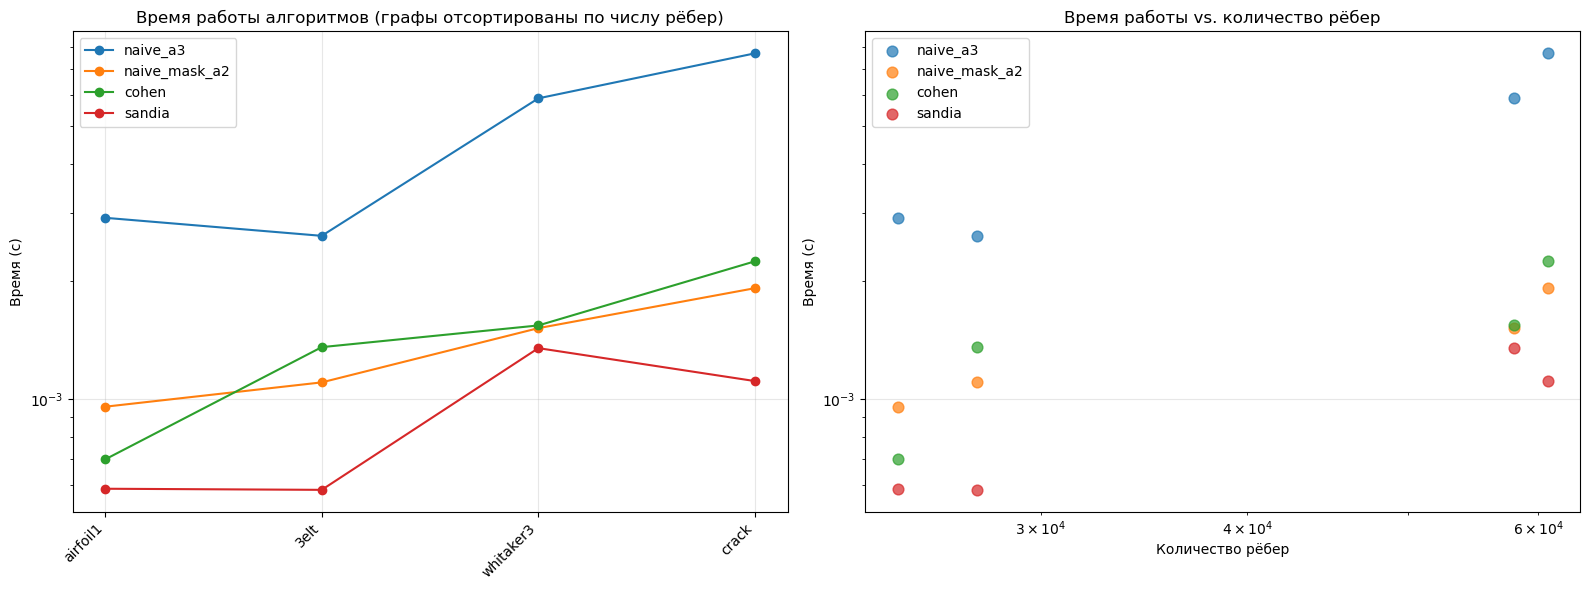

In [18]:
if len(ss_df) > 0:
    algo_cols = [c for c in ss_df.columns if c.endswith("_s")]
    algo_labels = [c.replace("_s", "") for c in algo_cols]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ss_sorted = ss_df.sort_values("edges")
    x = range(len(ss_sorted))

    for col, label in zip(algo_cols, algo_labels):
        axes[0].plot(x, ss_sorted[col], marker="o", label=label)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(ss_sorted["graph"], rotation=45, ha="right")
    axes[0].set_ylabel("Время (с)")
    axes[0].set_title("Время работы алгоритмов (графы отсортированы по числу рёбер)")
    axes[0].legend()
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)

    for col, label in zip(algo_cols, algo_labels):
        axes[1].scatter(ss_sorted["edges"], ss_sorted[col], label=label, alpha=0.7, s=60)
    axes[1].set_xlabel("Количество рёбер")
    axes[1].set_ylabel("Время (с)")
    axes[1].set_title("Время работы vs. количество рёбер")
    axes[1].legend()
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Выводы по SuiteSparse бенчмарку

Из 10 выбранных графов SuiteSparse Matrix Collection удалось загрузить 4 (airfoil1, whitaker3, crack, 3elt); остальные 6 вернули HTTP 404. По результатам бенчмарка на этих 4 графах:

1. **Naive A^3** -- стабильно самый медленный алгоритм на всех графах (2.6--7.7 мс). На наибольшем графе crack (10240 вершин, 60760 рёбер) время составило ~7.7 мс, что обусловлено необходимостью вычисления двух полных матричных произведений без маскирования.

2. **Naive Mask A^2** -- в 2.7--4x быстрее, чем Naive A^3, благодаря маскированию $A^2$ матрицей $A$. Время на тестовых графах: 0.95--1.9 мс. Маска позволяет пропустить вычисление элементов, для которых нет соответствующих рёбер в $A$.

3. **Cohen's algorithm** -- показал результаты, сопоставимые с Naive Mask A^2 (0.7--2.3 мс). На графе crack Cohen оказался медленнее Mask (2.3 мс против 1.9 мс), вероятно из-за накладных расходов на предварительное вычисление $L = \text{tril}(A)$ и $U = \text{triu}(A)$ для графов с относительно равномерным распределением рёбер.

4. **Sandia algorithm** -- стабильно самый быстрый алгоритм (0.58--1.3 мс). На графах airfoil1 и 3elt достиг времени ~0.6 мс, что в 4.5--7x быстрее Naive A^3. Использование только нижней треугольной части ($L \times L$ с маской $L$) минимизирует как объём входных данных, так и пространство результата.

5. **Масштабируемость**: разрыв между Naive A^3 и остальными алгоритмами растёт с увеличением размера графа. На малых графах (~4500 вершин) ускорение Sandia vs. Naive A^3 составляет ~4.5x, на графах ~10000 вершин -- уже ~7x. Это подтверждает, что маскирование и использование треугольных частей экономят тем больше вычислений, чем больше граф.

## Генератор случайных графов и исследование границ применимости

In [19]:
from scipy.sparse import random as sp_random, coo_matrix


def generate_random_graph(n: int, density: float, seed: int = 42) -> Matrix:
    """Генерация случайного неориентированного графа.

    Args:
        n: количество вершин
        density: степень разреженности (доля ненулевых элементов в верхнем треугольнике)
        seed: seed для воспроизводимости
    """
    rng = np.random.default_rng(seed)
    upper = sp_random(n, n, density=density, format="coo", random_state=rng,
                      data_rvs=lambda s: np.ones(s, dtype=np.int64))
    rows_u = upper.row
    cols_u = upper.col
    mask_upper = rows_u < cols_u
    r = np.concatenate([rows_u[mask_upper], cols_u[mask_upper]])
    c = np.concatenate([cols_u[mask_upper], rows_u[mask_upper]])
    vals = np.ones(len(r), dtype=np.int64)

    if len(r) == 0:
        return Matrix.new(dtypes.INT64, nrows=n, ncols=n)

    return Matrix.from_coo(r.tolist(), c.tolist(), vals.tolist(), nrows=n, ncols=n, dtype=dtypes.INT64)

In [20]:
# Проверка генератора
G_test = generate_random_graph(100, 0.1)
print(f"Test graph: {G_test.nrows} vertices, {G_test.nvals} directed edges")
assert is_undirected(G_test), "Generated graph must be undirected"
results_test = run_all(G_test)
values_test = list(results_test.values())
assert all(v == values_test[0] for v in values_test), f"Inconsistent: {results_test}"
print(f"All algorithms agree: {values_test[0]} triangles")
print("Generator: OK")

Test graph: 100 vertices, 994 directed edges
All algorithms agree: 177 triangles
Generator: OK


### Эксперимент: варьирование размера и плотности графа

In [21]:
SIZES = [100, 500, 1000, 3000, 5000]
DENSITIES = [0.001, 0.01, 0.05, 0.1]
TIMEOUT_S = 60

random_results = []

for n in SIZES:
    for d in DENSITIES:
        print(f"\nn={n}, density={d}")
        G = generate_random_graph(n, d, seed=n + int(d * 10000))
        actual_edges = G.nvals // 2
        print(f"  vertices={n}, undirected edges={actual_edges}")

        row = {"n": n, "density": d, "edges": actual_edges}

        for algo_name, fn in algorithms.items():
            try:
                start = time.perf_counter()
                result = fn(G)
                elapsed = time.perf_counter() - start
                if elapsed > TIMEOUT_S:
                    print(f"  {algo_name}: TIMEOUT (>{TIMEOUT_S}s)")
                    row[f"{algo_name}_s"] = None
                else:
                    row[f"{algo_name}_s"] = elapsed
                    row[f"{algo_name}_tri"] = result
                    print(f"  {algo_name}: {elapsed:.4f}s, triangles={result}")
            except Exception as e:
                print(f"  {algo_name}: ERROR: {e}")
                row[f"{algo_name}_s"] = None

        random_results.append(row)

rand_df = pd.DataFrame(random_results)
rand_df


n=100, density=0.001
  vertices=100, undirected edges=6
  naive_a3: 0.0007s, triangles=0
  naive_mask_a2: 0.0002s, triangles=0
  cohen: 0.0003s, triangles=0
  sandia: 0.0011s, triangles=0

n=100, density=0.01
  vertices=100, undirected edges=47
  naive_a3: 0.0001s, triangles=0
  naive_mask_a2: 0.0001s, triangles=0
  cohen: 0.0002s, triangles=0
  sandia: 0.0001s, triangles=0

n=100, density=0.05
  vertices=100, undirected edges=245
  naive_a3: 0.0003s, triangles=15
  naive_mask_a2: 0.0001s, triangles=15
  cohen: 0.0004s, triangles=15
  sandia: 0.0001s, triangles=15

n=100, density=0.1
  vertices=100, undirected edges=491
  naive_a3: 0.0007s, triangles=135
  naive_mask_a2: 0.0001s, triangles=135
  cohen: 0.0001s, triangles=135
  sandia: 0.0001s, triangles=135

n=500, density=0.001
  vertices=500, undirected edges=125
  naive_a3: 0.0001s, triangles=0
  naive_mask_a2: 0.0001s, triangles=0
  cohen: 0.0001s, triangles=0
  sandia: 0.0001s, triangles=0

n=500, density=0.01
  vertices=500, und

,n,density,edges,naive_a3_s,naive_a3_tri,naive_mask_a2_s,naive_mask_a2_tri,cohen_s,cohen_tri,sandia_s,sandia_tri
0,100,0.001,6,0.000725,0,0.000156,0,0.000282,0,0.001141,0
1,100,0.010,47,0.000110,0,0.000071,0,0.000213,0,0.000114,0
2,100,0.050,245,0.000316,15,0.000074,15,0.000361,15,0.000106,15
3,100,0.100,491,0.000659,135,0.000102,135,0.000122,135,0.000088,135
4,500,0.001,125,0.000103,0,0.000061,0,0.000106,0,0.000077,0
5,500,0.010,1253,0.001225,21,0.000111,21,0.000153,21,0.000112,21
6,500,0.050,6189,0.022035,2552,0.000466,2552,0.000507,2552,0.000331,2552
7,500,0.100,12431,0.017911,20150,0.001261,20150,0.000686,20150,0.000613,20150
8,1000,0.001,505,0.000296,1,0.000116,1,0.000184,1,0.000113,1
9,1000,0.010,5062,0.007696,173,0.000395,173,0.000317,173,0.000208,173


### Визуализация: зависимость времени от размера графа (при фиксированной плотности)

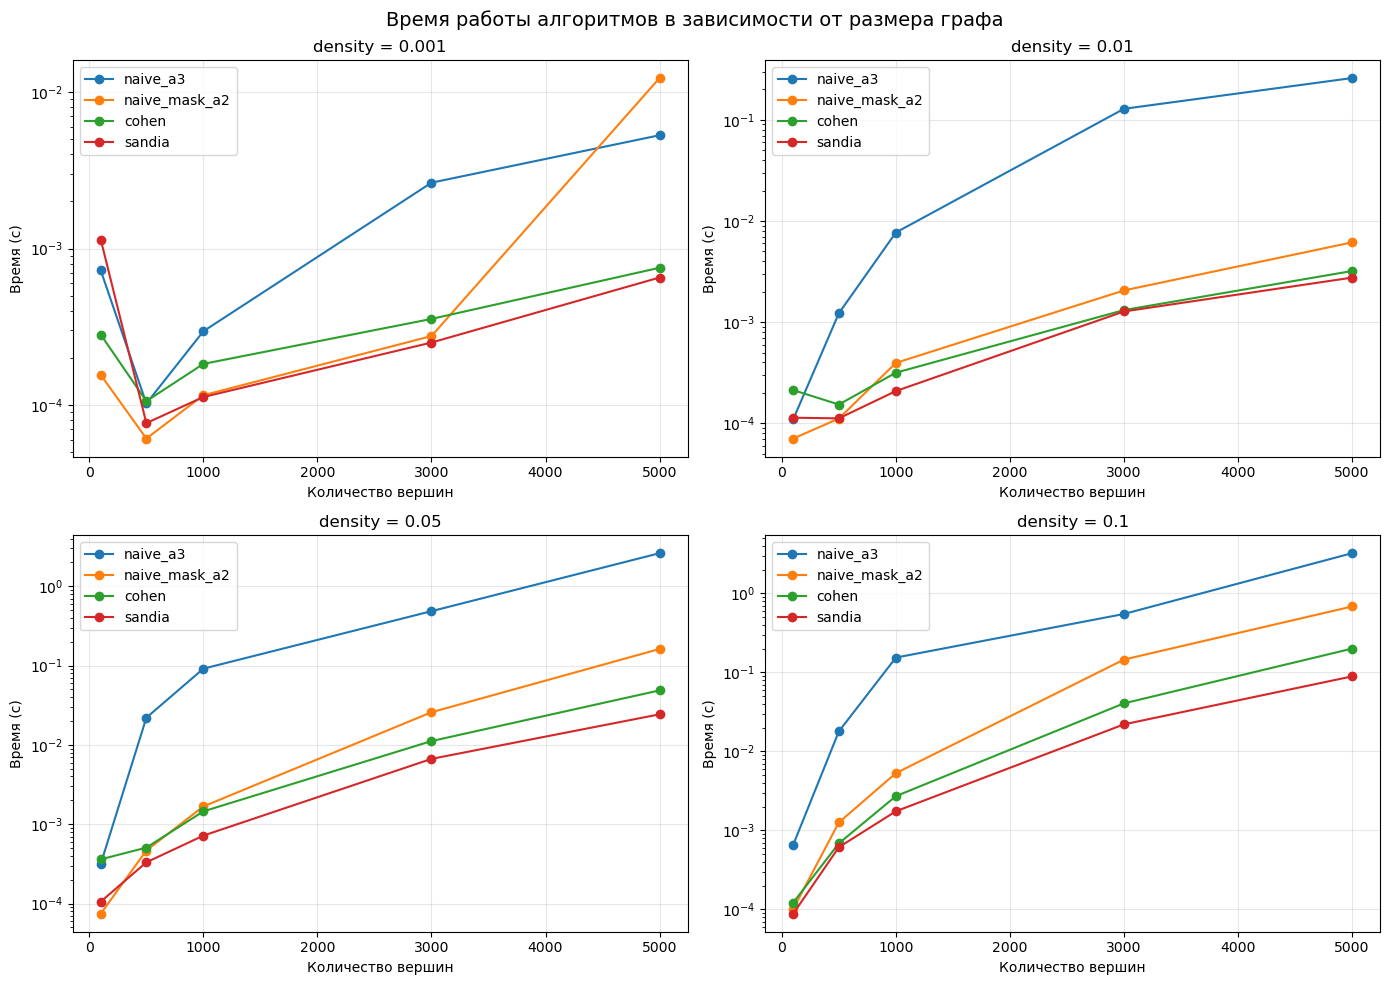

In [22]:
algo_cols = [c for c in rand_df.columns if c.endswith("_s")]
algo_labels = [c.replace("_s", "") for c in algo_cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, d in enumerate(DENSITIES):
    ax = axes[idx]
    subset = rand_df[rand_df["density"] == d].sort_values("n")
    for col, label in zip(algo_cols, algo_labels):
        vals = subset[col].values
        mask = pd.notna(vals)
        if mask.any():
            ax.plot(subset["n"].values[mask], vals[mask], marker="o", label=label)
    ax.set_xlabel("Количество вершин")
    ax.set_ylabel("Время (с)")
    ax.set_title(f"density = {d}")
    ax.legend()
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.suptitle("Время работы алгоритмов в зависимости от размера графа", fontsize=14)
plt.tight_layout()
plt.show()

### Визуализация: зависимость времени от плотности (при фиксированном размере)

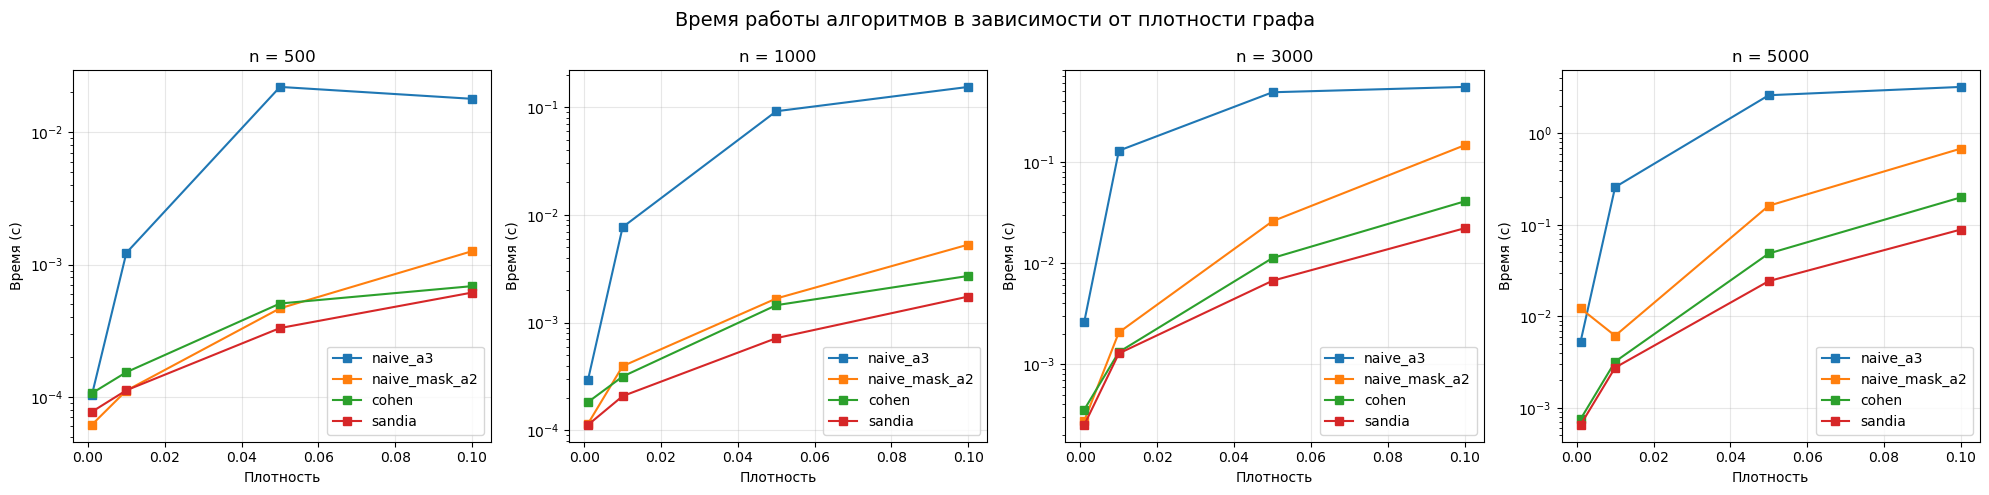

In [23]:
plot_sizes = [s for s in SIZES if s >= 500]

fig, axes = plt.subplots(1, len(plot_sizes), figsize=(5 * len(plot_sizes), 5))
if len(plot_sizes) == 1:
    axes = [axes]

for idx, n in enumerate(plot_sizes):
    ax = axes[idx]
    subset = rand_df[rand_df["n"] == n].sort_values("density")
    for col, label in zip(algo_cols, algo_labels):
        vals = subset[col].values
        mask = pd.notna(vals)
        if mask.any():
            ax.plot(subset["density"].values[mask], vals[mask], marker="s", label=label)
    ax.set_xlabel("Плотность")
    ax.set_ylabel("Время (с)")
    ax.set_title(f"n = {n}")
    ax.legend()
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.suptitle("Время работы алгоритмов в зависимости от плотности графа", fontsize=14)
plt.tight_layout()
plt.show()

### Выводы по генерации случайных графов

По результатам экспериментов на случайных графах с $n \in \{100, 500, 1000, 3000, 5000\}$ и $\text{density} \in \{0.001, 0.01, 0.05, 0.1\}$:

1. **Naive A^3** масштабируется хуже всего. При $n = 1000$, $d = 0.1$ время уже составляет 154 мс, при $n = 5000$, $d = 0.1$ -- 3.22 с. На самом крупном разреженном графе ($n = 5000$, $d = 0.05$) Naive A^3 выполняется 2.62 с, в то время как Sandia -- всего 24 мс (ускорение ~108x).

2. **Naive Mask A^2** значительно быстрее Naive A^3 на средних и крупных графах. Однако выигрыш уменьшается с ростом плотности: при $n = 5000$, $d = 0.1$ время Mask составило 682 мс (ускорение 4.7x относительно Naive A^3), тогда как при $n = 5000$, $d = 0.01$ -- 6.1 мс (ускорение 42x). Это объясняется тем, что при высокой плотности маска $A$ покрывает большую долю элементов $A^2$ и выигрыш от маскирования снижается.

3. **Cohen's algorithm** стабильно быстрее Mask A^2, особенно на плотных графах. При $n = 5000$, $d = 0.1$ Cohen работает за 200 мс -- в 3.4x быстрее Mask A^2. Умножение только треугольных частей ($L \times U$) вдвое сокращает число ненулевых элементов во входных матрицах.

4. **Sandia algorithm** -- стабильно самый быстрый алгоритм. При $n = 5000$, $d = 0.1$ Sandia выполняется за 89 мс (в 36x быстрее Naive A^3, в 2.2x быстрее Cohen). Работа только с нижним треугольником ($L \times L$, маска $L$) минимизирует как количество операций, так и объём промежуточных данных.

5. **Влияние плотности**: с ростом плотности время всех алгоритмов растёт сверхлинейно. Например, для Sandia при $n = 5000$: $d = 0.01 \to 2.8$ мс, $d = 0.05 \to 24$ мс (~9x), $d = 0.1 \to 89$ мс (~32x). Это объясняется квадратичной зависимостью числа путей длины 2 от количества рёбер.

6. **Границы применимости** (при таймауте 60 с):
   - **Naive A^3**: все конфигурации уложились в таймаут, но при $n = 5000$, $d = 0.1$ время уже 3.2 с. Экстраполяция показывает, что при $n \geq 10000$ и $d \geq 0.05$ время превысит десятки секунд.
   - **Naive Mask A^2**: при $n = 5000$, $d = 0.1$ время 682 мс. Приемлемо для разовых запусков, но при $n \geq 10000$ и высокой плотности может стать узким местом.
   - **Cohen / Sandia**: остаются быстрыми даже на самых крупных конфигурациях (89--200 мс при $n = 5000$, $d = 0.1$). Пригодны для значительно бо́льших графов.